# SR1 · Momentum: Winners Keep Winning (Mostly)

Momentum is one of the most studied and most robust patterns in finance: assets that have done well over the past year tend to keep doing well for a few more months. This notebook builds the two standard versions and looks honestly at how they behave.

## 1. Motivation

Classic finance theory says past prices shouldn't predict future returns: if they did, traders would exploit the pattern until it disappeared. Yet researchers have found momentum in stocks, bonds, currencies and commodities, in data going back over a century. Big quantitative funds run it at scale. For the Signal Research team, momentum is the natural first signal: simple to compute, well documented, and full of lessons about what makes a signal real.

## 2. Intuition

Why would winners keep winning? A few explanations, none of them complete:

- **Under-reaction.** News spreads slowly and investors update their views gradually, so prices drift in the direction of the news for months.
- **Herding.** Investors pile into what has been working, which pushes it further.
- **Risk.** Momentum strategies suffer rare but brutal crashes, so their returns may partly be payment for bearing that risk.

There are two ways to use the idea:

1. **Cross-sectional momentum** compares assets *with each other*: buy the best performers in the group, sell the worst. It is a bet on relative performance and is roughly market neutral.
2. **Time-series momentum** looks at each asset *on its own*: hold it if its own past return is positive, short it (or hold none) if negative. It is a bet on trends continuing, and it can be long or short the whole market.

## 3. The math

**The signal.** For asset $i$ at month-end $t$, the standard momentum signal is the return over the past 12 months, *skipping the most recent month*:
$$
s_{i,t} = \frac{P_{i,t-1}}{P_{i,t-12}} - 1 \qquad (\text{months}).
$$
The last month is skipped because very recent returns tend to *reverse* slightly (the short-term reversal effect from notebook 7).

**Cross-sectional portfolio.** Rank the $N$ assets by $s_{i,t}$. Hold the top third in equal weights (the **winners**, W) and short the bottom third (the **losers**, L). Next month's return is
$$
R^{\text{WML}}_{t+1} = \frac{1}{|W|}\sum_{i\in W} R_{i,t+1} \;-\; \frac{1}{|L|}\sum_{i\in L} R_{i,t+1}.
$$
"WML" stands for *winners minus losers*. This is a **portfolio sort**, the most common way to test whether a signal predicts returns.

**Time-series portfolio.** For each asset, take a position $\operatorname{sign}(s_{i,t})$ scaled to a volatility target, so that calm and volatile assets contribute similar risk (PR5):
$$
w_{i,t} = \operatorname{sign}(s_{i,t}) \cdot \frac{\sigma^{\text{target}}}{\hat\sigma_{i,t}}, \qquad R^{\text{TSMOM}}_{t+1} = \frac{1}{N}\sum_i w_{i,t} R_{i,t+1}.
$$

## 4. Code it

### 4.1 Setup: monthly data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

prices = pd.read_csv("../data/prices.csv", index_col="date", parse_dates=True)
meta = pd.read_csv("../data/meta.csv")

COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 100, "axes.prop_cycle": plt.cycler(color=COLORS),
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.3, "lines.linewidth": 1.5, "font.size": 11,
})
pd.set_option("display.width", 120)

monthly_px = prices.resample("ME").last()           # month-end prices
monthly_ret = monthly_px.pct_change()
rf_m = (monthly_px["^IRX"] / 100 / 12).shift(1)     # monthly risk-free rate known at the start of each month

stocks = meta.loc[meta.asset_type == "stock", "ticker"]
etfs = meta.loc[meta.asset_type == "etf", "ticker"]

def stats(r, rf=None):
    """Annualised stats for a monthly return series."""
    ex = r - (rf.reindex(r.index) if rf is not None else 0)
    v = (1 + r).cumprod()
    return pd.Series({"CAGR": f"{v.iloc[-1] ** (12 / len(r)) - 1:.1%}",
                      "Vol": f"{r.std() * np.sqrt(12):.1%}",
                      "Sharpe": f"{np.sqrt(12) * ex.mean() / ex.std():.2f}",
                      "Max DD": f"{(v / v.cummax() - 1).min():.1%}"})

### 4.2 Cross-sectional momentum on 43 stocks

In [2]:
signal = monthly_px[stocks].shift(1) / monthly_px[stocks].shift(12) - 1   # s_it: t-12 -> t-1 months

# Rank each month into thirds: 0 = losers, 1 = middle, 2 = winners
thirds = signal.rank(axis=1, pct=True).apply(lambda row: pd.cut(row, [0, 1/3, 2/3, 1], labels=False), axis=1)

next_ret = monthly_ret[stocks].shift(-1)        # return over the FOLLOWING month
groups = {}
for k, name in enumerate(["Losers", "Middle", "Winners"]):
    groups[name] = next_ret.where(thirds == k).mean(axis=1)   # equal-weight return of each third
groups = pd.DataFrame(groups).shift(1).dropna()               # shift back: label by the month the return happens
groups["WML"] = groups["Winners"] - groups["Losers"]

print("Average monthly return by group:")
print((groups.mean() * 100).round(2).astype(str) + "%")

Average monthly return by group:
Losers     1.26%
Middle     1.33%
Winners    1.44%
WML        0.18%
dtype: object


The `.shift(-1)` then `.shift(1)` pattern keeps the timing honest: the signal is formed at month-end $t$ using prices up to $t-1$, and it is paired with the return of month $t+1$.

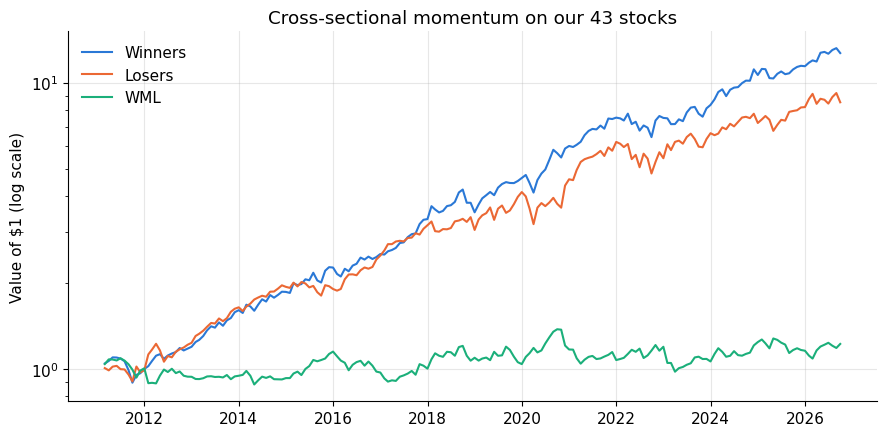

,CAGR,Vol,Sharpe,Max DD
Losers,14.7%,16.9%,0.80,-22.7%
Middle,16.2%,13.3%,1.08,-20.8%
Winners,17.6%,13.9%,1.13,-18.4%
WML,1.3%,12.8%,0.16,-28.9%


In [3]:
fig, ax = plt.subplots()
for col, c in [("Winners", COLORS[0]), ("Losers", COLORS[1]), ("WML", COLORS[2])]:
    ax.plot((1 + groups[col]).cumprod(), label=col, color=c)
ax.set_yscale("log")
ax.set_ylabel("Value of $1 (log scale)")
ax.set_title("Cross-sectional momentum on our 43 stocks")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

pd.DataFrame({c: stats(groups[c], rf_m if c != "WML" else None) for c in groups}).T

The signal points the right way, but weakly:

- **Returns line up with the signal.** Losers < middle < winners, both in average monthly return and in Sharpe ratio. This monotone pattern is what a real signal should produce.
- **But the long–short spread is small.** WML earned about 0.2% a month (Sharpe ≈ 0.16), with a −29% drawdown. Most of the gap between winners and losers is a few percentage points a year. On 43 large, heavily traded stocks, that is not enough for a stand-alone strategy.
- **Long-only "winners" looks great (Sharpe 1.13)**, but remember that *every* group here is flattered by survivorship (notebook 6). The meaningful comparison is between the groups, not against cash.

### 4.3 Is WML just market exposure?

In [4]:
mkt = monthly_ret["SPY"].reindex(groups.index)
beta = groups["WML"].cov(mkt) / mkt.var()
print(f"Beta of WML to SPY: {beta:.2f}")
print(f"Correlation with SPY: {groups['WML'].corr(mkt):.2f}")
worst = groups["WML"].nsmallest(5)
print("\nWorst WML months:")
print(pd.DataFrame({"WML": worst, "SPY that month": mkt[worst.index]}).map("{:+.1%}".format))

Beta of WML to SPY: -0.18
Correlation with SPY: -0.19

Worst WML months:
               WML SPY that month
date                             
2023-01-31  -12.2%          +6.3%
2020-11-30  -12.0%         +10.9%
2012-01-31  -11.3%          +4.6%
2018-10-31   -7.6%          -6.9%
2022-07-31   -7.3%          +9.2%


WML is close to market neutral (beta about −0.2), so it is a genuinely different source of return from just owning stocks. But look at *when* it loses most: in sharp rebounds. November 2020 (vaccine news), January 2023 and July 2022 were all big up-months for the market, led by the stocks that had fallen most. The short "loser" side then rallies hardest. These **momentum crashes** are the main risk of the strategy, and they are well documented over a century of data.

### 4.4 Time-series momentum on 18 ETFs

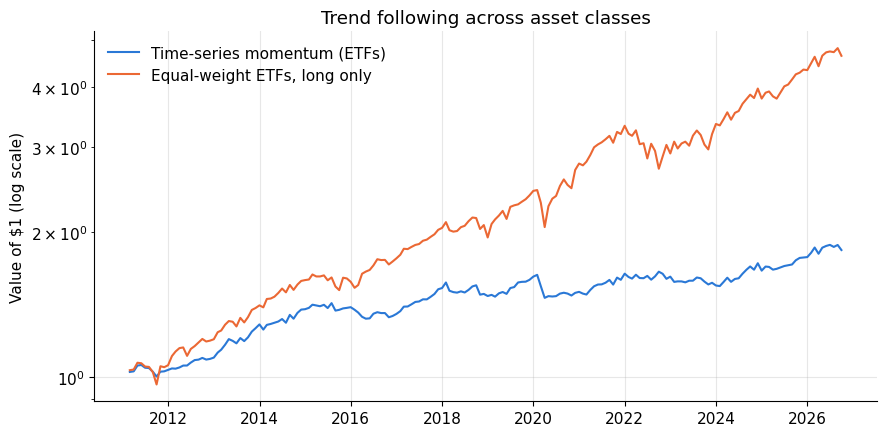

,CAGR,Vol,Sharpe,Max DD
TSMOM,3.9%,5.6%,0.44,-10.4%
Long-only ETFs,10.3%,10.9%,0.81,-18.6%


In [5]:
ts_signal = monthly_px[etfs].shift(1) / monthly_px[etfs].shift(12) - 1           # own 12-1 month return
daily_vol = prices[etfs].pct_change().rolling(63).std() * np.sqrt(252)
vol_m = daily_vol.resample("ME").last()                                            # vol known at month-end
w = np.sign(ts_signal) * (0.10 / vol_m)                                            # 10% vol target per asset
w = w.clip(-2, 2)                                                                  # cap leverage per asset

tsmom = (w * monthly_ret[etfs].shift(-1)).mean(axis=1).shift(1).dropna()           # next month's return
long_only = monthly_ret[etfs].mean(axis=1).reindex(tsmom.index)                    # equal weight, always long

fig, ax = plt.subplots()
ax.plot((1 + tsmom).cumprod(), label="Time-series momentum (ETFs)")
ax.plot((1 + long_only).cumprod(), label="Equal-weight ETFs, long only")
ax.set_yscale("log")
ax.set_ylabel("Value of $1 (log scale)")
ax.set_title("Trend following across asset classes")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

pd.DataFrame({"TSMOM": stats(tsmom, rf_m), "Long-only ETFs": stats(long_only, rf_m)}).T

Over the full sample, TSMOM earned less than simply holding all 18 ETFs (Sharpe 0.44 vs 0.81). 2010–2026 rewarded staying long. But it ran at about half the volatility and with about half the drawdown. The next table shows where its value comes from.

In [6]:
# When does TSMOM help? Its return in the worst months for the long-only portfolio
bad = long_only.nsmallest(6).index
pd.DataFrame({"Long-only ETFs": long_only[bad], "TSMOM": tsmom[bad]}).sort_index().map("{:+.1%}".format)

,Long-only ETFs,TSMOM
date,,
2018-12-31,-5.8%,-1.0%
2020-02-29,-5.9%,-5.3%
2020-03-31,-11.0%,-5.4%
2022-04-30,-6.4%,-1.6%
2022-06-30,-7.0%,+1.1%
2022-09-30,-8.2%,+2.3%


In the long-only portfolio's worst months, TSMOM lost much less, and in mid-2022 it made money. By then most trends were negative, so it was *short* bonds and stocks while both fell. It did not escape the first months of COVID: a crash that starts suddenly from a strong uptrend catches every trend follower long. This "crisis alpha" in slower bear markets is why trend-following funds are often used as a diversifier rather than a core holding.

## 5. Takeaways and where it breaks

- **Momentum is a real, well-documented effect**, and the 12-minus-1-month signal is the standard way to measure it.
- **Portfolio sorts are the basic test of any signal:** rank by the signal, form groups, and check that returns line up across the groups.
- **Our stock universe is too small and too biased for a strong conclusion.** 43 survivor stocks split into thirds gives about 14 stocks per side. Academic studies use thousands of stocks, including the ones that failed.
- **Momentum crashes.** WML loses heavily in sharp market rebounds, when beaten-down losers bounce hardest. A risk control (volatility scaling, PR5) is standard in practice.
- **Costs:** monthly rebalancing of thirds trades a lot of the portfolio. Check the break-even cost (notebook 7) before believing a gross number.

**What you could build:** a signal-testing harness: plug in any signal, get the portfolio sort, the WML return series, its market beta, worst months and break-even cost. The other notebooks in this track all produce signals that could be tested with it.